Now, we will explore some other pre-trained neural network architectures to see if the performance of the CNN-LSTM can be improved. We can first start with a VGG16, and then a VGG19, and then move on to a better network like the ResNets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

2025-03-07 09:56:20.127831: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-07 09:56:20.963731: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-07 09:56:20.963794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-07 09:56:21.112245: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-07 09:56:21.475247: I tensorflow/core/platform/cpu_feature_guar

In [2]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
# first load the train and validation data as in the previous model

# location of data files
all_data_loc = 'All_data'

# train blocks
train_blocks = ['block_0101', 'block_0102', 'block_0203', 'block_0301']

In [4]:
# get the density maps and the corresponding image subwindows so that they can be stacked for the train data
all_feature_subwindow_names = []
all_density_map_names =[]

for folder_name in train_blocks:
    path_name = os.path.join(all_data_loc, folder_name)
    density_map = [file for file in os.listdir(path_name)if file[:7] == 'density']
    feature_map = [file for file in os.listdir(path_name)if file[:7] == 'subwind']
    all_feature_subwindow_names.append(feature_map)
    all_density_map_names.append(density_map)

In [5]:
# load all feature maps
all_feature_maps = []
counter = 0
for item in np.array(all_feature_subwindow_names).flatten():
    load_map = np.load(os.path.join(all_data_loc, train_blocks[counter], item))
    all_feature_maps.append(load_map)
    counter = counter + 1

In [6]:
# load density maps
all_density_maps = []
counter = 0
for map in np.array(all_density_map_names).flatten():
    load_density_map = np.load(os.path.join(all_data_loc, train_blocks[counter], map))
    all_density_maps.append(load_density_map)
    counter = counter + 1

In [7]:
# check the shape of an item
all_density_maps[0].shape, all_feature_maps[0].shape

((12288, 7), (12288, 13, 32, 32, 3))

In [8]:
# how many items in each list?
len(all_density_maps), len(all_feature_maps)

(4, 4)

In [9]:
# stack all data together?

# I think we need to stack vertically
all_train_density_maps = np.vstack(all_density_maps)

all_train_feature_maps = np.vstack(all_feature_maps)

In [10]:
# check these shapes
all_train_density_maps.shape, all_train_feature_maps.shape

((49152, 7), (49152, 13, 32, 32, 3))

In [11]:
# we may need to do a sanity check to know if we have correctly stacked
for i in range(4):
    print(np.mean(all_density_maps[i] == all_train_density_maps[12288*i: 12288 + 12288*i,:]))

1.0
1.0
1.0
1.0


In [12]:
# for feature maps
for i in range(4):
    print(np.mean(all_feature_maps[i] == all_train_feature_maps[12288*i: 12288 + 12288*i,:]))

1.0
1.0
1.0
1.0


In [13]:
# Also need to load the validation data

# list the contents in the validation folder
all_valid_contents = os.listdir("All_data/block_0204")

In [14]:
all_valid_contents

['all_np_files',
 'subwindow_seqs_0204.npy',
 '.ipynb_checkpoints',
 'density_maps_seqs_0204.npy']

In [15]:
validation_feature_maps = np.load(os.path.join("All_data/block_0204", 'subwindow_seqs_0204.npy'))

In [16]:
validation_density_map = np.load(os.path.join("All_data/block_0204", 'density_maps_seqs_0204.npy'))

In [17]:
validation_feature_maps.shape, validation_density_map.shape

((12288, 13, 32, 32, 3), (12288, 7))

Now we move on to the pre-trained models.

In [18]:
# load the VGG16 model with keras - we will adjust the input size of the subwindows to match the base CNN model we use.

In [19]:
inputs = tf.keras.Input(shape = (None, 32, 32, 3))

In [20]:
resized_input = tf.keras.layers.TimeDistributed(tf.keras.layers.Resizing(224,224))(inputs)

In [21]:
base_model = tf.keras.applications.VGG16(weights = 'imagenet', include_top = False, input_shape = (224,224,3))

2025-03-07 09:58:23.621237: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:06:00.0, compute capability: 7.0


In [22]:
# see how this model looks like
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [23]:
# freeze all model layers here
for layer in base_model.layers:
    layer.trainable = False

In [24]:
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [25]:
# notice how the trainable parameters all changed to non-trainable parameters

In [26]:
# Add some custom layers at the end of the model. These layer weights will be trained when we train the CNN LSTM model

In [27]:
# 3. Add custom layers on top of the VGG16 base model
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # Apply global average pooling
x = tf.keras.layers.Dense(1024, activation='relu')(x)  # Add a fully connected layer
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)

In [28]:
new_model = tf.keras.models.Model(inputs = base_model.input, outputs = x)

In [29]:
new_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [30]:
525312 + 524800 + 32832

1082944

In [31]:
# Okay, now we define the CNN LSTM model

In [32]:
# time dist layer for the entire model
time_dist_layer = tf.keras.layers.TimeDistributed(new_model)

time_dist_output = time_dist_layer(resized_input)
time_dist_output

<KerasTensor: shape=(None, None, 64) dtype=float32 (created by layer 'time_distributed_1')>

In [33]:
lstm_layer = tf.keras.layers.LSTM(64)
lstm_output = lstm_layer(time_dist_output)
lstm_output

<KerasTensor: shape=(None, 64) dtype=float32 (created by layer 'lstm')>

In [34]:
# pred_layer_td = tf.keras.layers.TimeDistributed()
pred_layer = tf.keras.layers.Dense(7, activation = "relu")
# pred_time_dist_layer = tf.keras.layers.TimeDistributed(pred_layer)
pred_layer_out = pred_layer(lstm_output)
pred_layer_out

<KerasTensor: shape=(None, 7) dtype=float32 (created by layer 'dense_3')>

In [35]:
cnn_lstm = tf.keras.models.Model(inputs, pred_layer_out)
cnn_lstm.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, 32, 32, 3   0         
                             )]                                  
                                                                 
 time_distributed (TimeDist  (None, None, 224, 224,    0         
 ributed)                    3)                                  
                                                                 
 time_distributed_1 (TimeDi  (None, None, 64)          15797632  
 stributed)                                                      
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense_3 (Dense)             (None, 7)                 455       
                                                           

In [36]:
1082944 + 33024+455

1116423

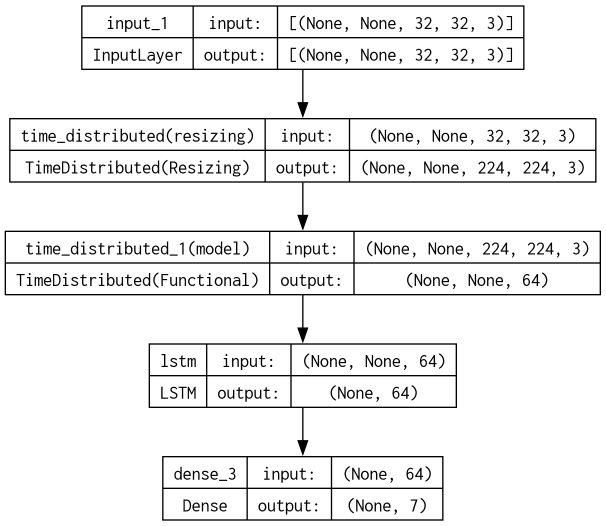

In [37]:
tf.keras.utils.plot_model(cnn_lstm, show_shapes = True)

In [38]:
# To use this model we need to resize the input data into (224,224,3) - and we did it in the model it self. So hopefully the rest of teh code should work without any problem.

In [39]:
# Define and add the generator function
def data_generator(x_data, y_data, batch_size, shuffle=False, peek=False, verbose=False):
    num_samples = len(x_data)
    indices = np.arange(num_samples)
    
    if peek:    # Give first batch unshuffled and don't change start index when peeking for training
        end = min(batch_size, num_samples)
        if verbose:
            print(f"Generating peeking batch up to index {end}")
        batch_x = x_data[:end]
        batch_y = y_data[:end]
        peek = False
        yield (batch_x, batch_y)

    while True:    # Loop indefinitely for epochs
        # Shuffle indices at the start of each epoch after the peek, if shuffle is enabled
        if shuffle:
            np.random.shuffle(indices)
        
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_indices = indices[start:end]

            # Print batch indices if verbose
            if verbose:
                # Warning: calling verbose when shuffling will usually clutter output
                if shuffle:
                    if len(batch_indices) < 16:
                        print(f"Batch indices: {np.sort(batch_indices)}")
                    else:
                        print(f"Printing batch indices would clutter output. Skipped.")
                    print(f"Length: {len(batch_indices)}")
                else:
                    print(f"Generating batch from index {start} to {end}")
                # traceback.print_stack()

            # Generate batches
            batch_x = x_data[batch_indices]
            batch_y = y_data[batch_indices]

            # Yield the current batch
            yield (batch_x, batch_y)

In [40]:
%%time
batch_size = 64
generator_batch_size = 64
train_gen = data_generator(all_train_feature_maps, all_train_density_maps, batch_size, shuffle=False, peek=True, verbose=False)
val_gen = data_generator(validation_feature_maps, validation_density_map, generator_batch_size, shuffle=False, peek=True, verbose=False)

CPU times: user 6 µs, sys: 9 µs, total: 15 µs
Wall time: 23.8 µs


In [41]:
steps_per_epoch = int(np.ceil(len(all_train_feature_maps) / batch_size))
train_steps = int(np.ceil(len(all_train_feature_maps) / generator_batch_size))
validation_steps = int(np.ceil(len(validation_feature_maps) / generator_batch_size))

In [42]:
%%time
# compile the model
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
cnn_lstm.compile(loss='mean_squared_error', optimizer=opt, metrics = ['mean_absolute_error'])
    
# add early stopping
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', restore_best_weights = True, verbose=1, patience=10)

# fit the generator - the steps are a must here
history = cnn_lstm.fit(train_gen,
          validation_data = val_gen, steps_per_epoch=steps_per_epoch, 
                                  validation_steps=validation_steps,           
          epochs = 100, callbacks = [es])

Epoch 1/100


2025-03-07 09:58:34.782889: W tensorflow/core/kernels/gpu_utils.cc:54] Failed to allocate memory for convolution redzone checking; skipping this check. This is benign and only means that we won't check cudnn for out-of-bounds reads and writes. This message will only be printed once.
2025-03-07 09:58:35.146629: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-03-07 09:59:20.576642: I external/local_xla/xla/service/service.cc:168] XLA service 0x14f3cc19a710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-03-07 09:59:20.576696: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-03-07 09:59:20.723971: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1741363161.332685 3865265 device_compiler.h:186] Compiled 

768/768 [==============================] - 1044s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0466 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 2/100
768/768 [==============================] - 992s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 3/100
768/768 [==============================] - 991s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 4/100
768/768 [==============================] - 992s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 5/100
768/768 [==============================] - 992s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 6/100
768/768 [==============================] - 993s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 7/100
768

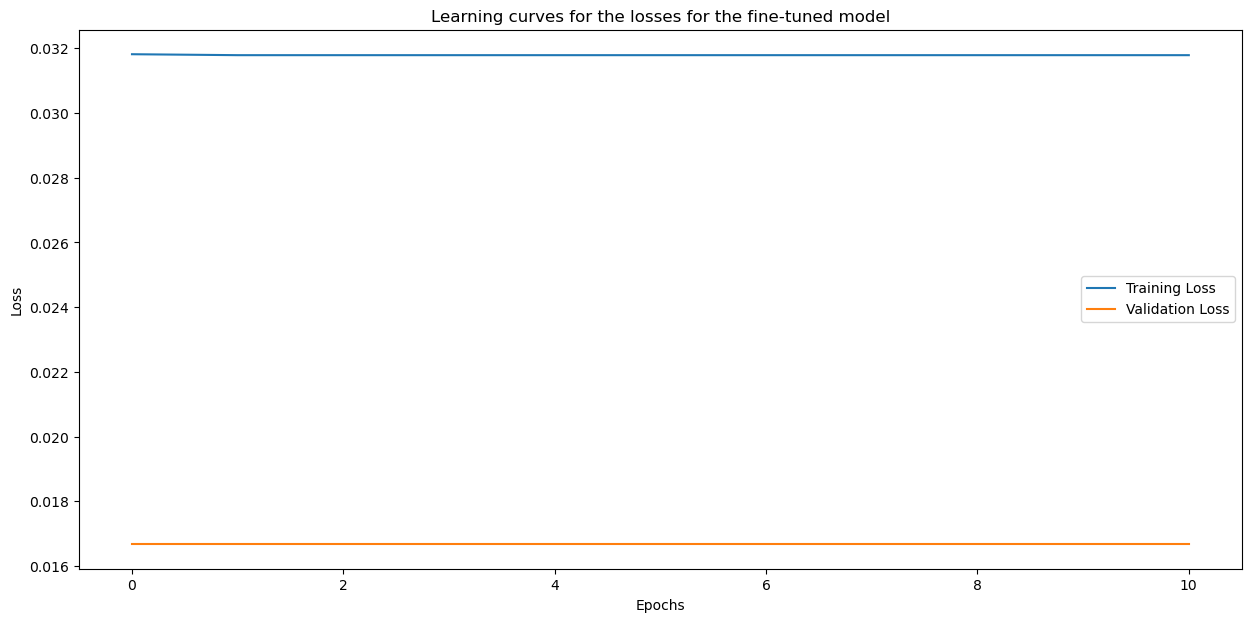

In [43]:
# plot the losses
plt.figure(figsize = (15,7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Learning curves for the losses for the fine-tuned model")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

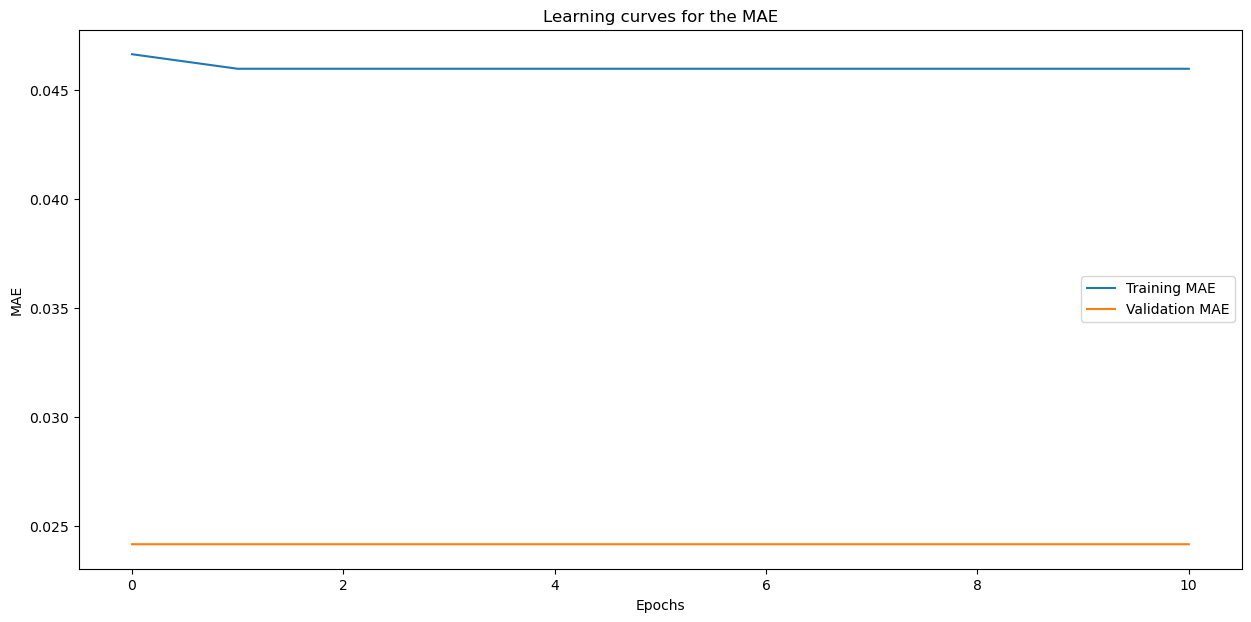

In [44]:
# plot the maes
plt.figure(figsize = (15,7))
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title("Learning curves for the MAE")
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [45]:
# save this model
model_name_frozen = 'VGG16_CNN_LSTM_frozen.keras'
cnn_lstm.save('models' + '/' + model_name_frozen)

In [46]:
for layer in base_model.layers[-4:]:
    layer.trainable = True

In [47]:
new_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [48]:
cnn_lstm.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, 32, 32, 3   0         
                             )]                                  
                                                                 
 time_distributed (TimeDist  (None, None, 224, 224,    0         
 ributed)                    3)                                  
                                                                 
 time_distributed_1 (TimeDi  (None, None, 64)          15797632  
 stributed)                                                      
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense_3 (Dense)             (None, 7)                 455       
                                                           

In [ ]:
%%time
# compile the model
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
cnn_lstm.compile(loss='mean_squared_error', optimizer=opt, metrics = ['mean_absolute_error'])
    
# add early stopping
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', restore_best_weights = True, verbose=1, patience=10)

# fit the generator - the steps are a must here
history_new = cnn_lstm.fit(train_gen,
          validation_data = val_gen, steps_per_epoch=steps_per_epoch, 
                                  validation_steps=validation_steps,           
          epochs = 100, callbacks = [es])

Epoch 1/100
768/768 [==============================] - 1081s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 2/100
768/768 [==============================] - 1067s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 3/100
768/768 [==============================] - 1067s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 4/100
768/768 [==============================] - 1067s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 5/100
768/768 [==============================] - 1067s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.0242
Epoch 6/100
768/768 [==============================] - 1067s 1s/step - loss: 0.0318 - mean_absolute_error: 0.0460 - val_loss: 0.0167 - val_mean_absolute_error: 0.024

In [ ]:
# plot the losses
plt.figure(figsize = (15,7))
plt.plot(history_new.history['loss'], label='Training Loss')
plt.plot(history_new.history['val_loss'], label='Validation Loss')
plt.title("Learning curves for the losses for the fine-tuned model")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize = (15,7))
plt.plot(history_new.history['mean_absolute_error'], label='Training MAE')
plt.plot(history_new.history['val_mean_absolute_error'], label='Validation MAE')
plt.title("Learning curves for the MAE for the fine-tuned model")
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [ ]:
# save this model
model_name_finetuned = 'VGG16_CNN_LSTM_finetuned.keras'
cnn_lstm.save('models' + '/' + model_name_finetuned)